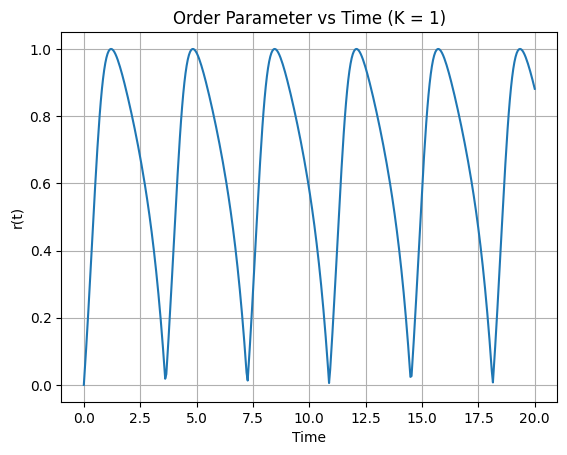

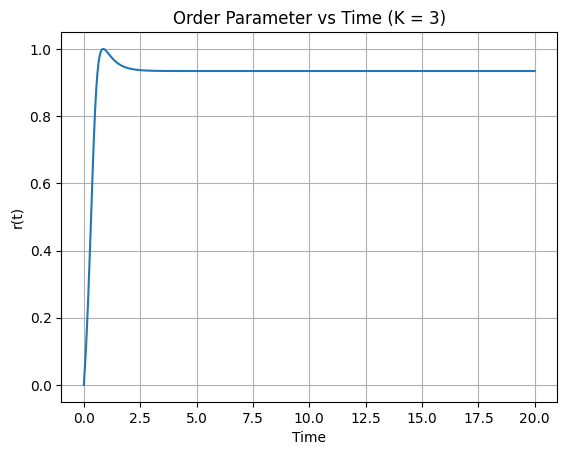

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ---------- PARAMETERS ----------
N = 2
omega = np.array([0.5, 2.5])
t = np.linspace(0, 20, 400)
theta0 = np.array([0.0, np.pi])

# ---------- KURAMOTO FUNCTION ----------
def kuramoto(theta, t, omega, K, N):
    d_theta = np.zeros(N)
    for i in range(N):
        coupling = (K / N) * np.sum(np.sin(theta - theta[i]))
        d_theta[i] = omega[i] + coupling
    return d_theta

# ---------- ORDER PARAMETER ----------
def compute_r(sol):
    r = []
    for theta in sol:
        complex_order = np.exp(1j * theta)
        r.append(np.abs(np.sum(complex_order) / N))
    return np.array(r)

# ---------- RUN FOR K = 1 ----------
K1 = 1.0
sol1 = odeint(kuramoto, theta0, t, args=(omega, K1, N))
r1 = compute_r(sol1)

plt.figure()
plt.plot(t, r1)
plt.xlabel("Time")
plt.ylabel("r(t)")
plt.title("Order Parameter vs Time (K = 1)")
plt.grid()
plt.show()

# ---------- RUN FOR K = 3 ----------
K2 = 3.0
sol2 = odeint(kuramoto, theta0, t, args=(omega, K2, N))
r2 = compute_r(sol2)

plt.figure()
plt.plot(t, r2)
plt.xlabel("Time")
plt.ylabel("r(t)")
plt.title("Order Parameter vs Time (K = 3)")
plt.grid()
plt.show()